In [ ]:
import requests
import pandas as pd

# only for the yc oss api
tags = [
    "ai",
    "machine-learning",
    "generative-ai",
    "ai-assistant",
    "ai-enhanced-learning",
    "ai-powered-drug-discovery",
    "aiops",
    "artificial-intelligence",
    "ml",
    "nlp",
    "data-engineering",
    "data-science",
    "analytics",
    "big-data",
    "computer-vision",
    "deep-learning",
    # "b2b",
    "conversational-ai",
    "devops",
    "developer-tools"
]


# TODO: remove some keywords for redundancy, they may not be causal...
keywords = [
    "AI",
    "Machine Learning",
    "Generative AI",
    "AI Assistant",
    "AI-Enhanced Learning",
    "AI-powered Drug Discovery",
    "AIOps",
    "Artificial Intelligence",
    "ML",
    "NLP",
    "Data Engineering",
    "Data Science",
    "Analytics",
    "Big Data",
    "Computer Vision",
    "Deep Learning",
    # "B2B",
    "Conversational AI",
    "DevOps",
    "Developer Tools"
]


infos = {}
response = requests.get("https://yc-oss.github.io/api/companies/all.json")
if response.status_code == 200:
    data = response.json()
    for company in data:
        infos[company['id']] = company['status']


In [3]:
import pandas as pd

companies = pd.read_csv("kaggle_yc/companies.csv")
tags = pd.read_csv("kaggle_yc/tags.csv")

filter_tech = False # set to True only if you want to limit to certain tags

companies = companies.drop(columns=["Unnamed: 0"])

if filter_tech:
    keyword_tags = tags[tags["tag"].isin(keywords)]
    keyword_company_ids = keyword_tags["id"].unique()
    filtered_companies = companies[companies["id"].isin(keyword_company_ids)] # only filter if you want to limit to certain tags
    print("failures before updating with API:", (filtered_companies["status"] == "Inactive").sum())
    filtered_companies["status"] = filtered_companies["id"].apply(lambda x: infos[x] if x in infos else filtered_companies[filtered_companies["id"] == x]["status"].values[0])
    print("failures after updating with API:", (filtered_companies["status"] == "Inactive").sum())
else:
    keyword_tags = tags
    filtered_companies = companies
    print("failures before updating with API:", (filtered_companies["status"] == "Inactive").sum())
    filtered_companies["status"] = filtered_companies["id"].apply(lambda x: infos[x] if x in infos else filtered_companies[filtered_companies["id"] == x]["status"].values[0])
    print("failures after updating with API:", (filtered_companies["status"] == "Inactive").sum())

filtered_companies = filtered_companies[filtered_companies["id"].notnull()]

filtered_companies = filtered_companies.merge(
    keyword_tags.groupby("id")["tag"].apply(list).reset_index().rename(columns={"tag": "tags"}),
    on="id",
    how="left"
)

# focus on the last 10 years
drops = ["S05", "W06", "S06", "S07", "W07", "S08", "W08", "S09", "W09", "S10", "W10", "S11", "W11", "S12", "W12", "S13", "W13"]

filtered_companies = filtered_companies[~filtered_companies["batch"].isin(drops)]

failed = filtered_companies[filtered_companies["status"] == "Inactive"].reset_index(drop=True)
acquired = filtered_companies[filtered_companies["status"] == "Acquired"].reset_index(drop=True)
active = filtered_companies[filtered_companies["status"] == "Active"].reset_index(drop=True)
active = pd.concat([active, filtered_companies[filtered_companies["status"] == "Public"]])

failed_by_batch = failed.groupby("batch").size()
acquired_by_batch = acquired.groupby("batch").size()
active_by_batch = active.groupby("batch").size()


all_batches = sorted(
    set(failed_by_batch.index) | set(active_by_batch.index) | set(acquired_by_batch.index),
    key=lambda x: x[1:3].zfill(2) + x[0] # year first then season
)

failed_by_batch = failed_by_batch.reindex(all_batches, fill_value=0)
active_by_batch = active_by_batch.reindex(all_batches, fill_value=0)
acquired_by_batch = acquired_by_batch.reindex(all_batches, fill_value=0)

print("failed", failed_by_batch.sum(), "active", active_by_batch.sum(), "acquired", acquired_by_batch.sum(), "total", 
      failed_by_batch.sum()+active_by_batch.sum()+acquired_by_batch.sum())

failures before updating with API: 805
failures after updating with API: 976
failed 733 active 3043 acquired 511 total 4287


In [4]:
failed.head()

,id,name,slug,website,smallLogoUrl,oneLiner,longDescription,teamSize,url,batch,status,tags
0,644,Whirlscape,whirlscape,http://getdango.com,https://bookface-images.s3.amazonaws.com/small...,Mobile keyboards + emoji + deep learning. We m...,Whirlscape high-tech startup with roots in hum...,3.0,https://www.ycombinator.com/companies/whirlscape,W14,Inactive,[Deep Learning]
1,638,AirPair,airpair,http://airpair.com,NaN,Instant access to the world's best software ex...,"Develop Better Software, Faster!\r\n\r\nAirPai...",2.0,https://www.ycombinator.com/companies/airpair,W14,Inactive,[Remote Work]
2,635,ZowPow,zowpow,http://zowpow.com,NaN,Wireless toy game controllers for mobile games.,ZowPow is a Wireless toy game controllers for ...,2.0,https://www.ycombinator.com/companies/zowpow,W14,Inactive,[Gaming]
3,629,Unicornly,unicornly,https://unicorn.ly,NaN,Unicorn.ly makes fundraising more efficient fo...,Unicorn.ly is an angel investing platform to h...,2.0,https://www.ycombinator.com/companies/unicornly,W14,Inactive,"[Fintech, Investing]"
4,627,Terravion,terravion,http://terravion.com,NaN,Real time Google Earth for agriculture -- imag...,TerrAvion provides high revisit rate aerial im...,11.0,https://www.ycombinator.com/companies/terravion,W14,Inactive,"[Drones, Agriculture]"


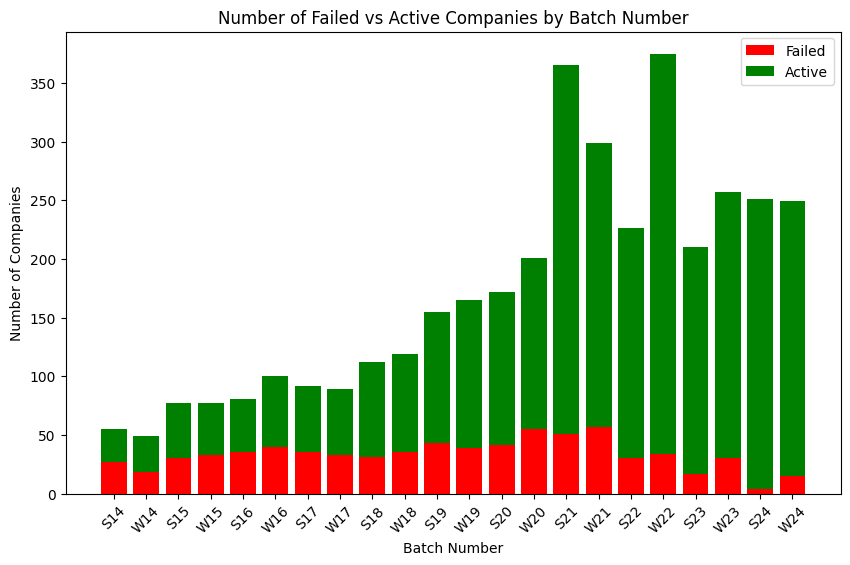

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(failed_by_batch.index, failed_by_batch.values, label="Failed", color='red')
plt.bar(active_by_batch.index, active_by_batch.values, bottom=failed_by_batch.values, label="Active", color='green')
plt.xlabel("Batch Number")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45)
plt.title("Number of Failed vs Active Companies by Batch Number")
plt.legend()
plt.show()

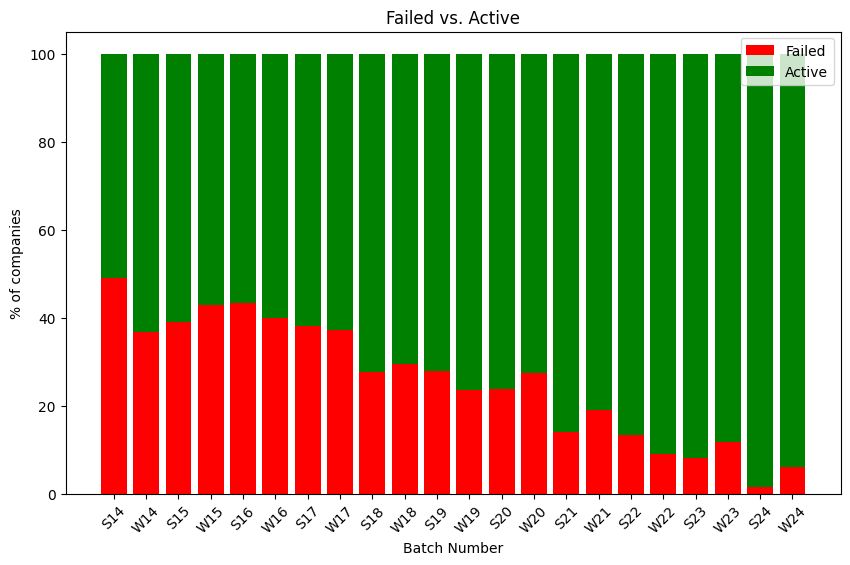

In [6]:
total_by_batch = failed_by_batch + active_by_batch
failed_percentage = (failed_by_batch / total_by_batch) * 100
active_percentage = (active_by_batch / total_by_batch) * 100
plt.figure(figsize=(10, 6))
plt.bar(failed_percentage.index, failed_percentage.values, label="Failed", color='red')
plt.bar(active_percentage.index, active_percentage.values, bottom=failed_percentage.values, label="Active", color='green')
plt.xlabel("Batch Number")
plt.ylabel("% of companies")
plt.xticks(rotation=45)
plt.title("Failed vs. Active")
plt.legend()
plt.show()

In [8]:
import os

def merge_thing(df, region_df):
    print("original df size", len(df))
    ids = set(df["id"].unique())
    # tags = pd.read_csv("kaggle_yc/tags.csv")
    region_df = region_df[region_df["id"].isin(ids)]
    region_df = region_df[["id", "country"]]
    df = df.merge(region_df, on="id", how="left")
    print("merged df size", len(df))
    return df

regions = pd.read_csv("kaggle_yc/regions.csv")
failed_df = merge_thing(failed, regions)
active_df = merge_thing(active, regions)
acquired_df = merge_thing(acquired, regions)

os.makedirs("updated_data", exist_ok=True)

failed_df[["id", "name", "batch", "longDescription", "country", "tags", "status"]].to_csv("updated_data/failed_companies.csv", index=False)
active_df[["id", "name", "batch", "longDescription", "country", "tags", "status"]].to_csv("updated_data/active_companies.csv", index=False)
acquired_df[["id", "name", "batch", "longDescription", "country", "tags", "status"]].to_csv("updated_data/acquired_companies.csv", index=False)

original df size 733
merged df size 733
original df size 3043
merged df size 3043
original df size 511
merged df size 511
